В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
import kaggle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import operator
import os
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_squared_error, roc_curve, auc
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, RobustScaler, PolynomialFeatures, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import zipfile

Accuracy: 87.42%
F1-score: 0.64
Area under ROC score on Train dataset: 0.75%


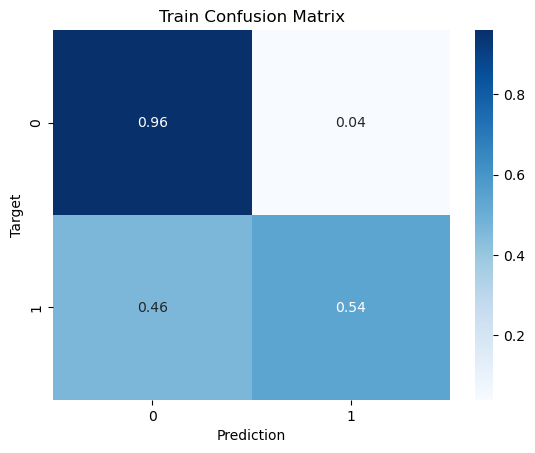

Accuracy: 87.17%
F1-score: 0.64
Area under ROC score on Validation dataset: 0.76%


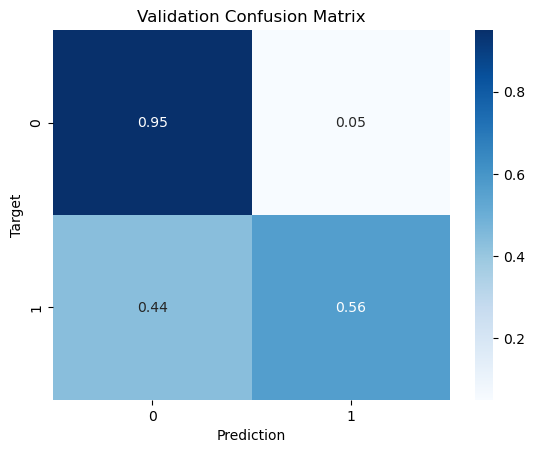

['work_log_model_pipeline.joblib']

In [2]:
train_val_df = pd.read_csv("bank_data/train.csv", index_col=0)

train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[2:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    print(f"F1-score: {f1_score(targets, preds):.2f}")
    fpr, tpr, _ = roc_curve(targets, preds)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'work_log_model_pipeline.joblib')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Accuracy: 89.25%
F1-score: 0.70
Area under ROC score on Train dataset: 0.79%


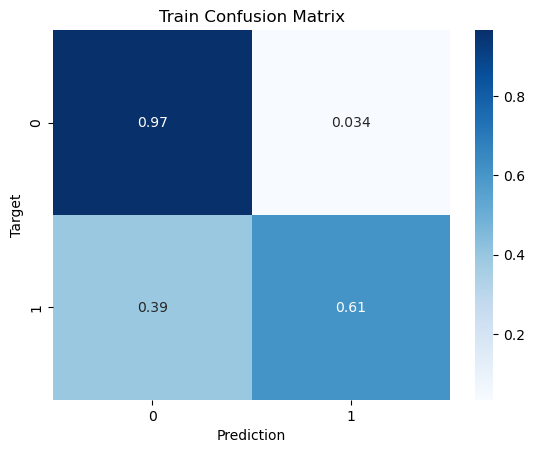

Accuracy: 88.83%
F1-score: 0.69
Area under ROC score on Validation dataset: 0.79%


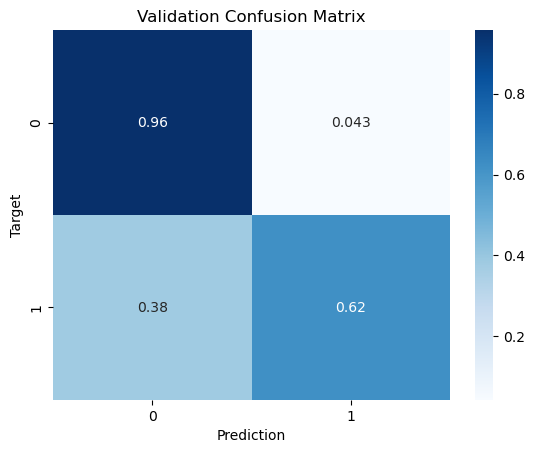

['work_log_model_pipeline_poly_2.joblib']

In [3]:
train_val_df = pd.read_csv("bank_data/train.csv", index_col=0)

train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[2:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_poly_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_poly_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l2', C=1))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    print(f"F1-score: {f1_score(targets, preds):.2f}")
    fpr, tpr, _ = roc_curve(targets, preds)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'work_log_model_pipeline_poly_2.joblib')

**Висновок**:

Модель з 2 степенем поліному:
1) Модель стала кращою:
- приріст точності ≈ +1.6%
- приріст F1 ≈ +0.05
- приріст ROC AUC ≈ +0.03

2) Модель не переобучилась:
- Train AUC: 0.79
- Test AUC: 0.79
Різниця майже нульова - генералізація чудова.

3) Модель стала більш гнучкою, але не втратила стабільність.
Поліноми другого степеня додають взаємодії між ознаками, і логістична регресія добре це використовує.

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Accuracy: 90.26%
F1-score: 0.74
Area under ROC score on Train dataset: 0.82%


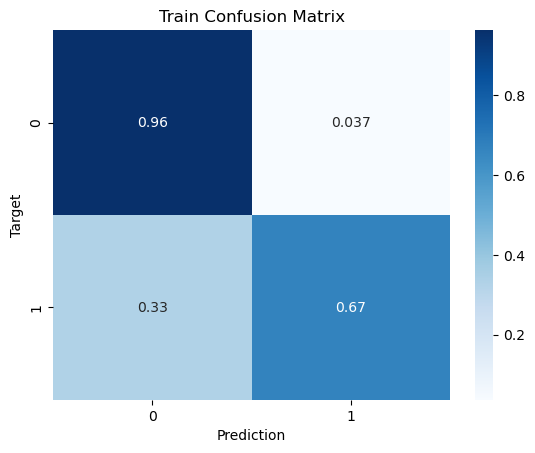

Accuracy: 89.63%
F1-score: 0.72
Area under ROC score on Validation dataset: 0.81%


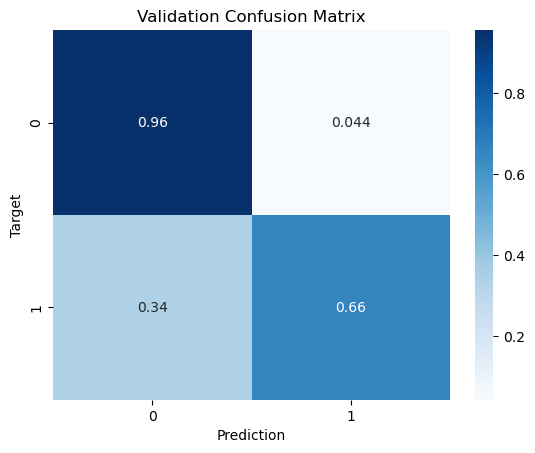

['work_log_model_pipeline_poly_4.joblib']

In [4]:
train_val_df = pd.read_csv("bank_data/train.csv", index_col=0)

train_df, val_df = train_test_split(train_val_df, test_size=0.2, random_state=42, stratify=train_val_df['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[2:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include='object').columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_poly_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4, include_bias=False))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_poly_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', penalty='l2', C=1))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    print(f"F1-score: {f1_score(targets, preds):.2f}")
    fpr, tpr, _ = roc_curve(targets, preds)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'work_log_model_pipeline_poly_4.joblib')

**Висновок**:

Моделі зі степенем 4:
1) Модель стала ще кращою:
- Train AUC: 0.82
- Test AUC: 0.81
- F1 зріс до 0.72
- Accuracy майже 90%
2) Легке збільшення розриву між Train і Test
- Train AUC: 0.82
- Test AUC: 0.81

Отже:
- Різниця між train/test мінімальна. Overfitting немає
- Модель не “завчила” шум, хоча стала складнішою. Underfitting теж немає
- Навпаки - модель краще вловлює нелінійні залежності. Модель добре генералізує

**Фінальний підсумок**:
Додавання поліноміальних ознак в цій задачі суттєво покращує якість логістичної регресії.
Модель зі степенем 2 показує стабільне покращення без ознак переобучення.
Модель зі степенем 4 дає найкращі результати (AUC ≈ 0.81–0.82, F1 ≈ 0.72), при цьому різниця між Train і Test мінімальна, що свідчить про хорошу генералізацію.
Жодних ознак overfit чи underfit не спостерігається - модель адекватно масштабується зі збільшенням складності.

Щодо результатів на тестувальних даних у змаганні, то на даному етапі найкращі резyльтати показала модель з 2 рівнем поліному і регуляризацією L1 сильнішою від стандартної.

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [5]:
reg_df = pd.read_csv("data/regression_data.csv")

train_reg_df, val_reg_df = train_test_split(reg_df, test_size=0.2, random_state=42)

# Створюємо трен. і вал. набори
input_reg_cols = list(train_reg_df.columns)[:-1]
target_reg_col = 'target'
train_reg_inputs, train_reg_targets = train_reg_df[input_reg_cols].copy(), train_reg_df[target_reg_col].copy()
val_reg_inputs, val_reg_targets = val_reg_df[input_reg_cols].copy(), val_reg_df[target_reg_col].copy()

In [6]:
reg_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,target
count,129.000000,129.000000,129.000000,129.000000,129.000000,129.000000
mean,-0.082039,-0.017872,0.092293,-0.076084,0.053098,-3.902984
std,0.941214,1.065887,0.978557,0.910588,1.004498,45.466621
min,-3.241267,-2.619745,-1.913280,-2.211135,-2.301921,-111.753810
25%,-0.699726,-0.756351,-0.553649,-0.730367,-0.772825,-37.339533
50%,-0.066080,-0.161286,0.120296,0.018418,0.013002,-0.641298
75%,0.529804,0.679598,0.624120,0.519347,0.787085,25.464414
max,2.122156,3.852731,3.078881,2.314659,2.075401,115.125907


In [7]:
def train_lin_vs_poly_reg_and_plot(X_train, X_val, y_train, y_val, degree):

    # --- Масштабування ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)

    # --- Звичайна лінійна регресія ---
    lin_reg = LinearRegression()
    lin_reg.fit(X_train_scaled, y_train)

    y_pred_train_lin = lin_reg.predict(X_train_scaled)
    y_pred_val_lin = lin_reg.predict(X_val_scaled)

    # --- Поліноміальна регресія ---
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly_features.fit_transform(X_train_scaled)
    X_val_poly = poly_features.transform(X_val_scaled)

    print(f'В оригінальній матриці {X_train.shape[1]} ознак.')
    print(f'В матриці з поліноміальними ознаками {X_train_poly.shape[1]} ознак.\n')

    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, y_train)

    y_pred_train_poly = poly_reg.predict(X_train_poly)
    y_pred_val_poly = poly_reg.predict(X_val_poly)

    # --- Оцінка моделей ---
    rmse_lin_train = np.sqrt(mean_squared_error(y_train, y_pred_train_lin))
    rmse_lin_val = np.sqrt(mean_squared_error(y_val, y_pred_val_lin))

    rmse_poly_train = np.sqrt(mean_squared_error(y_train, y_pred_train_poly))
    rmse_poly_val = np.sqrt(mean_squared_error(y_val, y_pred_val_poly))

    print(f"Train RMSE for Linear Regression: {rmse_lin_train:.3f}")
    print(f"Test RMSE for Linear Regression: {rmse_lin_val:.3f}\n")

    print(f"Train RMSE for Polynomial Regression (degree {degree}): {rmse_poly_train:.3f}")
    print(f"Test RMSE for Polynomial Regression (degree {degree}): {rmse_poly_val:.3f}")

In [8]:
degree = 2
train_lin_vs_poly_reg_and_plot(train_reg_inputs, val_reg_inputs, train_reg_targets, val_reg_targets, degree)

В оригінальній матриці 5 ознак.
В матриці з поліноміальними ознаками 20 ознак.

Train RMSE for Linear Regression: 1.066
Test RMSE for Linear Regression: 0.883

Train RMSE for Polynomial Regression (degree 2): 1.017
Test RMSE for Polynomial Regression (degree 2): 1.015


In [9]:
degree = 3
train_lin_vs_poly_reg_and_plot(train_reg_inputs, val_reg_inputs, train_reg_targets, val_reg_targets, degree)

В оригінальній матриці 5 ознак.
В матриці з поліноміальними ознаками 55 ознак.

Train RMSE for Linear Regression: 1.066
Test RMSE for Linear Regression: 0.883

Train RMSE for Polynomial Regression (degree 3): 0.799
Test RMSE for Polynomial Regression (degree 3): 1.916


In [10]:
degree = 4
train_lin_vs_poly_reg_and_plot(train_reg_inputs, val_reg_inputs, train_reg_targets, val_reg_targets, degree)

В оригінальній матриці 5 ознак.
В матриці з поліноміальними ознаками 125 ознак.

Train RMSE for Linear Regression: 1.066
Test RMSE for Linear Regression: 0.883

Train RMSE for Polynomial Regression (degree 4): 0.000
Test RMSE for Polynomial Regression (degree 4): 18.803


In [11]:
degree = 5
train_lin_vs_poly_reg_and_plot(train_reg_inputs, val_reg_inputs, train_reg_targets, val_reg_targets, degree)

В оригінальній матриці 5 ознак.
В матриці з поліноміальними ознаками 251 ознак.

Train RMSE for Linear Regression: 1.066
Test RMSE for Linear Regression: 0.883

Train RMSE for Polynomial Regression (degree 5): 0.000
Test RMSE for Polynomial Regression (degree 5): 35.628


**Висновок**
Базова лінійна модель добре генералізує без використання полінома і з поліномом 2 рівня, з поліномом 3 рівня помилка на тестовому наборі зростає в двічі, і далі зі зростанням полінома видно, що модель перенавчилась (помилка на тренувальному наборі 0, а помилка на тесті геометрично зростає)

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [12]:
models = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    ElasticNet()
]

In [13]:
import warnings

warnings.filterwarnings("ignore")

all_results = []

# --- Масштабування ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_reg_inputs)
X_val_scaled = scaler.transform(val_reg_inputs)

for degree in range(1, 21):

    # --- Поліноміальні ознаки ---
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_val_poly = poly.transform(X_val_scaled)

    for model in models:
        m = clone(model).fit(X_train_poly, train_reg_targets)

        train_rmse = np.sqrt(mean_squared_error(train_reg_targets, m.predict(X_train_poly)))
        val_rmse = np.sqrt(mean_squared_error(val_reg_targets, m.predict(X_val_poly)))

        all_results.append({
            "degree": degree,
            "model": model.__class__.__name__,
            "train": round(train_rmse, 2),
            "val": round(val_rmse, 2)
        })

df_results = pd.DataFrame(all_results)

In [14]:
df_pivot = df_results.pivot(
    index="degree",
    columns="model",
    values=["train", "val"]
)

In [15]:
df_pivot = df_pivot.sort_index(axis=1, level=1)

In [16]:
df_pivot

,train,val,train,val,train,val,train,val
model,ElasticNet,ElasticNet,Lasso,Lasso,LinearRegression,LinearRegression,Ridge,Ridge
degree,,,,,,,,
1,15.07,16.86,1.48,1.39,1.07,0.88,1.15,0.94
2,14.99,16.41,1.48,1.39,1.02,1.01,1.11,1.13
3,11.88,21.26,1.77,1.82,0.80,1.92,1.54,6.82
4,10.84,15.49,1.77,1.84,0.00,18.80,1.35,25.22
5,10.23,33.28,1.84,3.19,0.00,35.63,1.14,28.44
6,10.07,68.82,1.87,2.67,0.00,50.42,1.10,105.63
7,9.49,36.98,1.94,7.79,0.00,91.85,1.07,70.80
8,9.41,200.24,1.99,3.45,0.00,123.33,1.07,438.11


| Модель             | Train RMSE      | Val RMSE        | Поведінка                                      |
|--------------------|------------------|------------------|------------------------------------------------|
| LinearRegression   | ↓ до **0.00**    | ↑ до **~**         | Сильний overfitting через мультиколінеарність                          |
| Ridge              | стабільно        | ↑ до **177,059**   | М’який overfitting, Найкраща генералізація, згладжені коефіцієнти      |
| Lasso              | ↑ плавно         | ↑ до **233**       | Відбір ознак, але втрата інформації при високих степенях               |
| ElasticNet         | ↓ до ~**10**     | ↑ до **241**       | Компроміс між L1 і L2, стабільна, але менш точна                       |

**Висновки по кожній моделі**

1) LinearRegression — найгірша генералізація
- Train RMSE падає до 0.00 вже на степені 4.
- Val RMSE вибухає до мільйонів.
- Це класичний overfitting через мультиколінеарність.
- Модель нестабільна, коефіцієнти вибухають, розв’язок деградує.
  
2) Ridge — найкраща генералізація серед усіх моделей
- Train RMSE ≈ 1.06–1.15 (стабільно до 15 полінома).
- Val RMSE росте, але повільніше ніж в LinearRegression.
- Навіть на високих степенях Ridge не вибухає так катастрофічно, як LinearRegression чи ElasticNet.
- L2‑регуляризація згладжує коефіцієнти, зменшує мультиколінеарність і зберігає інформацію з усіх поліномів.
  
Висновок: Ridge - найкраща модель для узагальнення в цьому випадку через регуляцію залежності існуючих ознак, які тільки сильнішають в поліномах.

3) Lasso — стабільна, але слабка генералізація
- Train RMSE зростає (модель стає надто простою).
- Val RMSE росте до 233+.
- L1‑штраф зануляє більшість поліномів → модель втрачає інформацію.
- На високих степенях Lasso не може відновити складні залежності.
Висновок: занадто агресивна регуляризація, слабка точність.

4) ElasticNet — стабільна, але не найточніша
- Train RMSE ≈ 9–15 (стабільно).
- Val RMSE росте до 200–400.
- Комбінація L1+L2 дає стабільність, але L1‑частина все одно занадто сильно обрізає ознаки.
- Модель не вибухає, але й не дає найкращої точності.

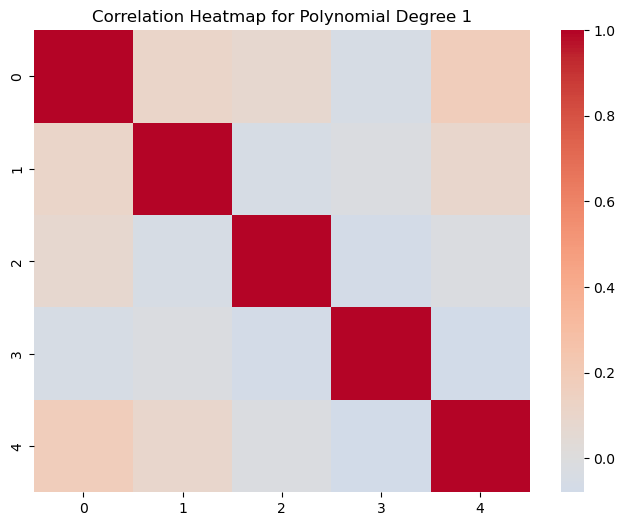

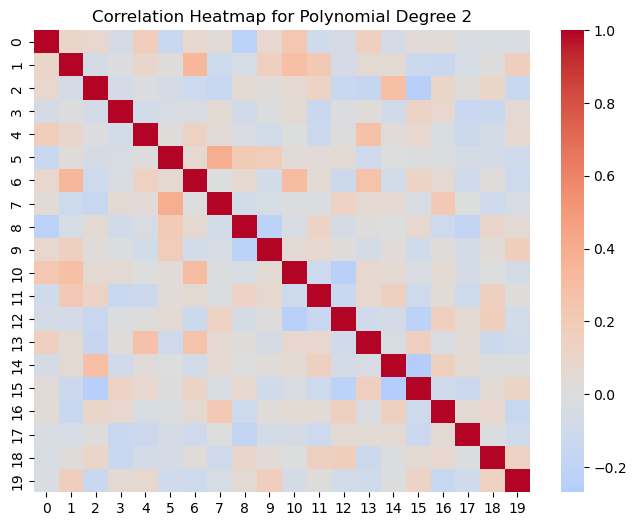

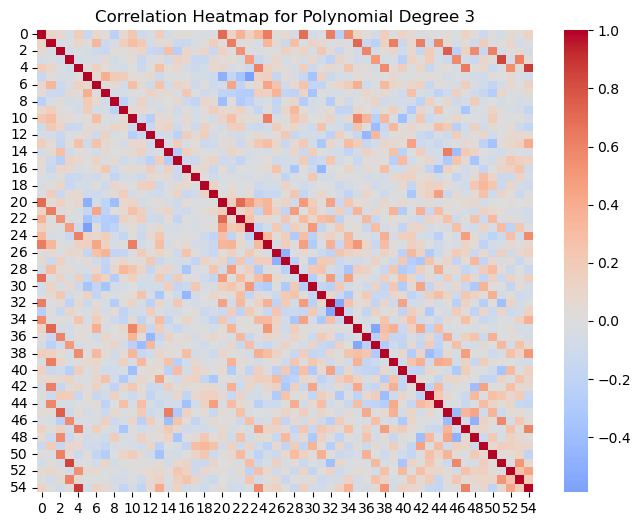

In [17]:
for degree in range(1, 4):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(train_reg_inputs)

    corr = pd.DataFrame(X_poly).corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, cmap="coolwarm", center=0)
    plt.title(f"Correlation Heatmap for Polynomial Degree {degree}")
    plt.show()

In [18]:
def compute_vif(X):
    vif = []
    for i in range(X.shape[1]):
        vif.append(variance_inflation_factor(X, i))
    return vif

vif_results = {}

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(train_reg_inputs)

    vif_values = compute_vif(X_poly)
    vif_results[degree] = vif_values

    print(f"\nDegree {degree}:")
    print("Max VIF:", max(vif_values))
    print("Median VIF:", np.median(vif_values))


Degree 1:
Max VIF: 1.0490050115121365
Median VIF: 1.02001178268048

Degree 2:
Max VIF: 1.857027021609592
Median VIF: 1.383738234653889

Degree 3:
Max VIF: 28.638197622103025
Median VIF: 9.282779718168433

Degree 4:
Max VIF: inf
Median VIF: inf

Degree 5:
Max VIF: inf
Median VIF: inf


In [19]:
coef_history = {m.__class__.__name__: [] for m in models}

for degree in range(1, 21):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(train_reg_inputs)

    for model in models:
        fresh = clone(model)
        fresh.fit(X_poly, train_reg_targets)

        coef_history[model.__class__.__name__].append(fresh.coef_)

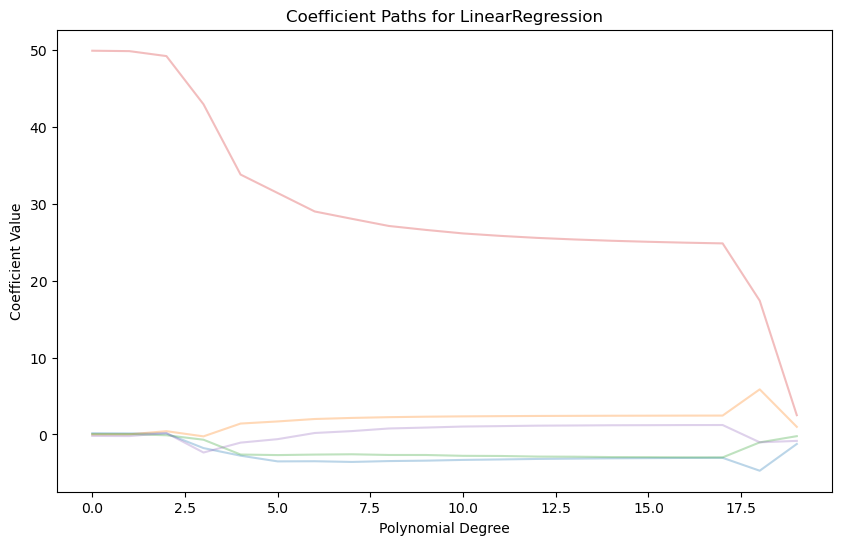

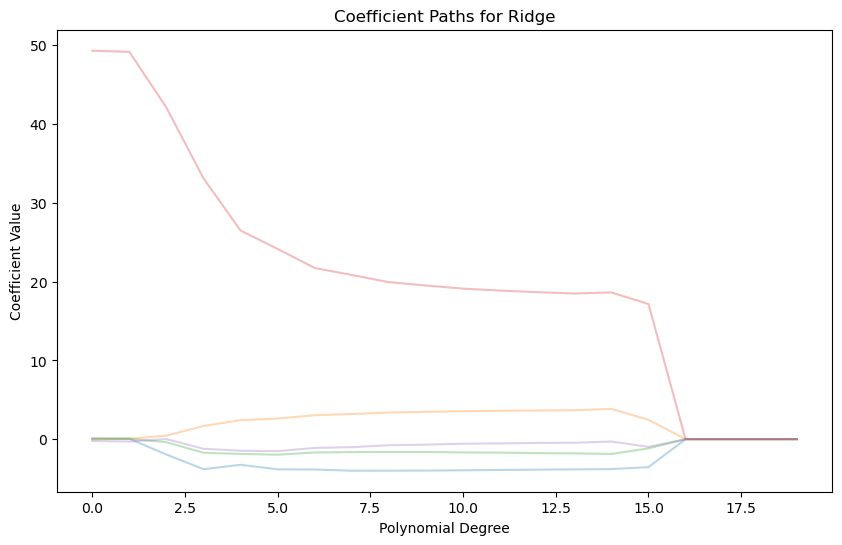

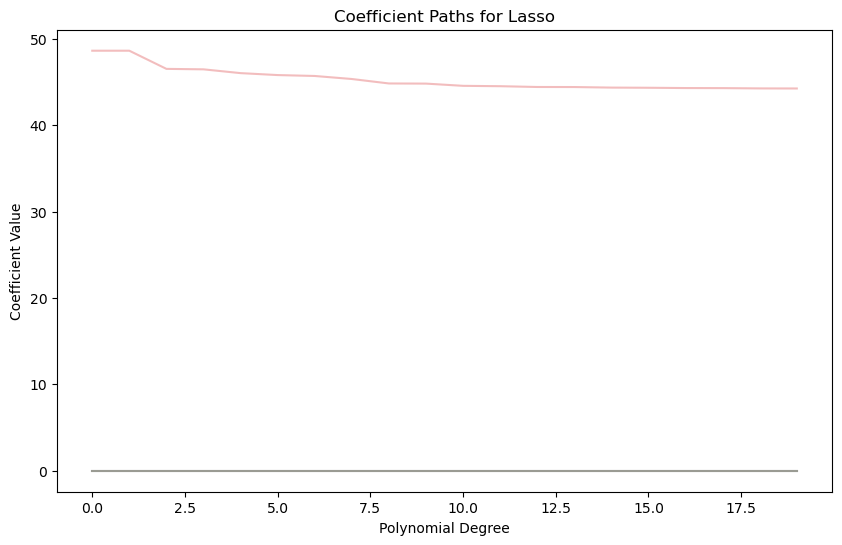

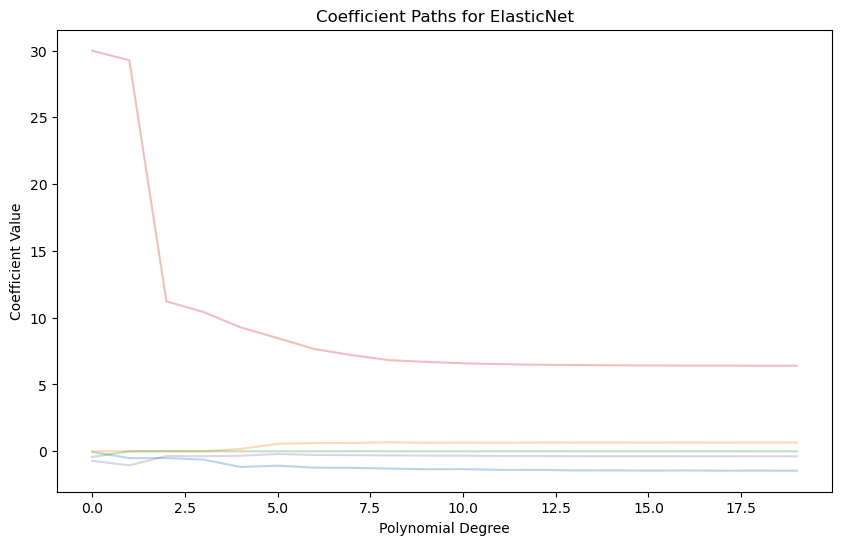

In [20]:
for model_name, coefs in coef_history.items():
    plt.figure(figsize=(10, 6))
    for i in range(len(coefs[0])):  
        plt.plot([c[i] for c in coefs], label=f"coef {i}", alpha=0.3)
    plt.title(f"Coefficient Paths for {model_name}")
    plt.xlabel("Polynomial Degree")
    plt.ylabel("Coefficient Value")
    plt.show()